# Participant Embedding Explorer

This notebook explores participant-level embeddings generated from metadata + xlsx timeseries.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent
ARTIFACTS = ROOT / "artifacts"
EMB_PATH = ARTIFACTS / "participant_embeddings.csv"
UMAP_PATH = ARTIFACTS / "participant_umap.csv"
MANIFEST_PATH = ARTIFACTS / "feature_manifest.json"

print("Artifacts:", ARTIFACTS)
print("Embeddings exists:", EMB_PATH.exists())
print("UMAP exists:", UMAP_PATH.exists())
print("Manifest exists:", MANIFEST_PATH.exists())

Artifacts: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts
Embeddings exists: True
UMAP exists: True
Manifest exists: True


In [6]:
emb = pd.read_csv(EMB_PATH)
um = pd.read_csv(UMAP_PATH)

display(emb.head())
display(um.head())

,group,participant,injury_status,sex,injured_leg,pace_coverage_count,emb_001,emb_002,emb_003,emb_004,...,emb_023,emb_024,emb_025,emb_026,emb_027,emb_028,emb_029,emb_030,emb_031,emb_032
0,ACLD,ACLD1,ACL deficient,Male,left,3,-4.771492,51.009449,45.738001,-3.917494,...,11.197032,1.555516,3.541005,-1.769363,6.318264,5.116527,13.885730,-0.240418,-4.657760,20.919690
1,ACLD,ACLD10,ACL deficient,Female,right,3,-40.209162,-40.418143,-50.055627,-1.772903,...,11.939451,9.311695,-13.345657,-0.386606,-11.617149,-10.198687,11.758669,-3.369474,-3.655993,-2.003053
2,ACLD,ACLD11,ACL deficient,Male,left,3,-43.866652,-25.410222,-35.591655,19.924449,...,-4.403695,8.308651,-12.531391,-14.346734,-14.443816,-3.732288,-0.059869,4.224853,-0.806300,-7.919346
3,ACLD,ACLD12,ACL deficient,Male,right,3,-13.796441,10.220070,31.135201,20.646688,...,5.427144,-11.863407,-0.504085,11.784527,13.571366,-2.910830,-3.168157,7.616770,1.636212,-2.824394
4,ACLD,ACLD13,ACL deficient,Male,left,3,-36.905083,-20.206900,-28.879922,2.320264,...,10.596245,3.033250,-16.284910,-5.579928,-3.684348,-11.928827,-9.885744,12.702838,-0.814587,-1.198564


,group,participant,injury_status,sex,pace_coverage_count,umap_x,umap_y,umap_z
0,ACLD,ACLD1,ACL deficient,Male,3,-4.771492,51.009449,45.738001
1,ACLD,ACLD10,ACL deficient,Female,3,-40.209162,-40.418143,-50.055627
2,ACLD,ACLD11,ACL deficient,Male,3,-43.866652,-25.410222,-35.591655
3,ACLD,ACLD12,ACL deficient,Male,3,-13.796441,10.220070,31.135201
4,ACLD,ACLD13,ACL deficient,Male,3,-36.905083,-20.206900,-28.879922


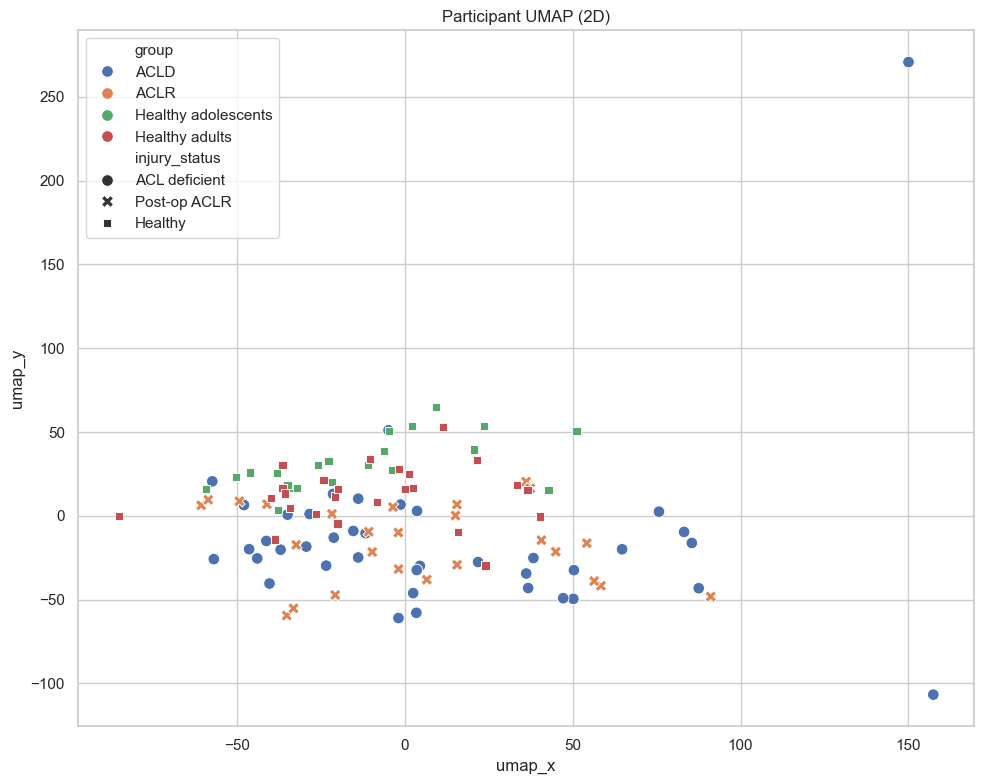

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=um,
    x="umap_x",
    y="umap_y",
    hue="group" if "group" in um.columns else None,
    style="injury_status" if "injury_status" in um.columns else None,
    s=70,
    ax=ax,
)
ax.set_title("Participant UMAP (2D)")
plt.tight_layout()
plt.show()

In [8]:
if "missing_pace_any" in emb.columns:
    print("Missing pace(any) participants:", int(emb["missing_pace_any"].sum()))
if "pace_coverage_count" in emb.columns:
    print(emb["pace_coverage_count"].value_counts(dropna=False).sort_index())

pace_coverage_count
3    114
Name: count, dtype: int64


In [9]:
emb_cols = [c for c in emb.columns if c.startswith("emb_")]
X = emb[emb_cols].to_numpy(dtype=float)
nn = NearestNeighbors(n_neighbors=min(6, len(emb)), metric="euclidean")
nn.fit(X)

def nearest_participants(participant_id: str, top_k: int = 5):
    if participant_id not in set(emb["participant"].astype(str)):
        raise ValueError(f"participant not found: {participant_id}")
    idx = emb.index[emb["participant"].astype(str) == participant_id][0]
    dist, ind = nn.kneighbors(X[idx].reshape(1, -1), n_neighbors=min(top_k + 1, len(emb)))
    rows = emb.iloc[ind[0]].copy()
    rows["distance"] = dist[0]
    if "injury_status" in rows.columns and "pace_coverage_count" in rows.columns:
        return rows[["group", "participant", "injury_status", "pace_coverage_count", "distance"]]
    return rows[["group", "participant", "distance"]]

# Example:
# nearest_participants("HA1", top_k=5)

## Bias / Coverage quick checks
- Group counts in embedding outputs
- Pace coverage distribution
- Optional nearest-neighbor spot checks by participant

In [10]:
display(emb.groupby("group").size().rename("participants").to_frame())
if "injury_status" in emb.columns:
    display(emb.groupby(["group", "injury_status"]).size().rename("n").to_frame())

,participants
group,
ACLD,40
ACLR,27
Healthy adolescents,22
Healthy adults,25


,,n
group,injury_status,
ACLD,ACL deficient,40
ACLR,Post-op ACLR,26
Healthy adolescents,Healthy,22
Healthy adults,Healthy,25
